In [9]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML

# Import data

In [10]:
df = spoti.load_all_tracks(base_path=data_path.DATA_PATH, users=users_list.USERS, load_spotify_tracks=True)
df

,album,artists,available_markets,disc_number,duration_ms,episode,explicit,external_ids,external_urls,href,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,affinity,release_year,normalized_genres
0,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,251488,False,False,{'isrc': 'GBF088590110'},{'spotify': 'https://open.spotify.com/track/4R...,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,...,audio_features,spotify:track:4RvWPyQ5RL0ao9LPZeSouE,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,https://api.spotify.com/v1/audio-analysis/4RvW...,251489,4,NaN,NaN,NaN,NaN
1,"{'album_type': 'compilation', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,256146,False,False,{'isrc': 'GBF088590112'},{'spotify': 'https://open.spotify.com/track/74...,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,...,audio_features,spotify:track:748yv6bb3l3CcKS45a6SZ8,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,https://api.spotify.com/v1/audio-analysis/748y...,256147,4,NaN,NaN,NaN,NaN
2,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,209106,False,False,{'isrc': 'GBUM71103440'},{'spotify': 'https://open.spotify.com/track/7n...,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,...,audio_features,spotify:track:7nhWtCc3v6Vem80gYPlppQ,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,https://api.spotify.com/v1/audio-analysis/7nhW...,209107,4,NaN,NaN,NaN,NaN
3,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,170786,False,False,{'isrc': 'GBUM71029609'},{'spotify': 'https://open.spotify.com/track/4v...,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,...,audio_features,spotify:track:4vhVDkSx9RSb2k6mWFMYNI,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,https://api.spotify.com/v1/audio-analysis/4vhV...,170787,4,NaN,NaN,NaN,NaN
4,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,264253,False,False,{'isrc': 'GBUM71029621'},{'spotify': 'https://open.spotify.com/track/5R...,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,...,audio_features,spotify:track:5RYLa5P4qweEAKq5U1gdcK,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,https://api.spotify.com/v1/audio-analysis/5RYL...,264253,4,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20061,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,211213,False,True,{'isrc': 'IT4U11700019'},{'spotify': 'https://open.spotify.com/track/07...,https://api.spotify.com/v1/tracks/07VhWcjtxG9f...,...,audio_features,spotify:track:07VhWcjtxG9fe1jZixSY3F,https://api.spotify.com/v1/tracks/07VhWcjtxG9f...,https://api.spotify.com/v1/audio-analysis/07Vh...,211213,4,NaN,NaN,2017.0,"[rap, pop, indie]"
20062,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,162864,False,False,{'isrc': 'USAT21904486'},{'spotify': 'https://open.spotify.com/track/6r...,https://api.spotify.com/v1/tracks/6rVNnvyNeibt...,...,audio_features,spotify:track:6rVNnvyNeibts1uOqdSNIw,https://api.spotify.com/v1/tracks/6rVNnvyNeibt...,https://api.spotify.com/v1/audio-analysis/6rVN...,162864,3,NaN,NaN,2019.0,"[pop, pop]"
20063,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,143791,False,True,{'isrc': 'USAT21903333'},{'spotify': 'https://open.spotify.com/tr

# Distribution

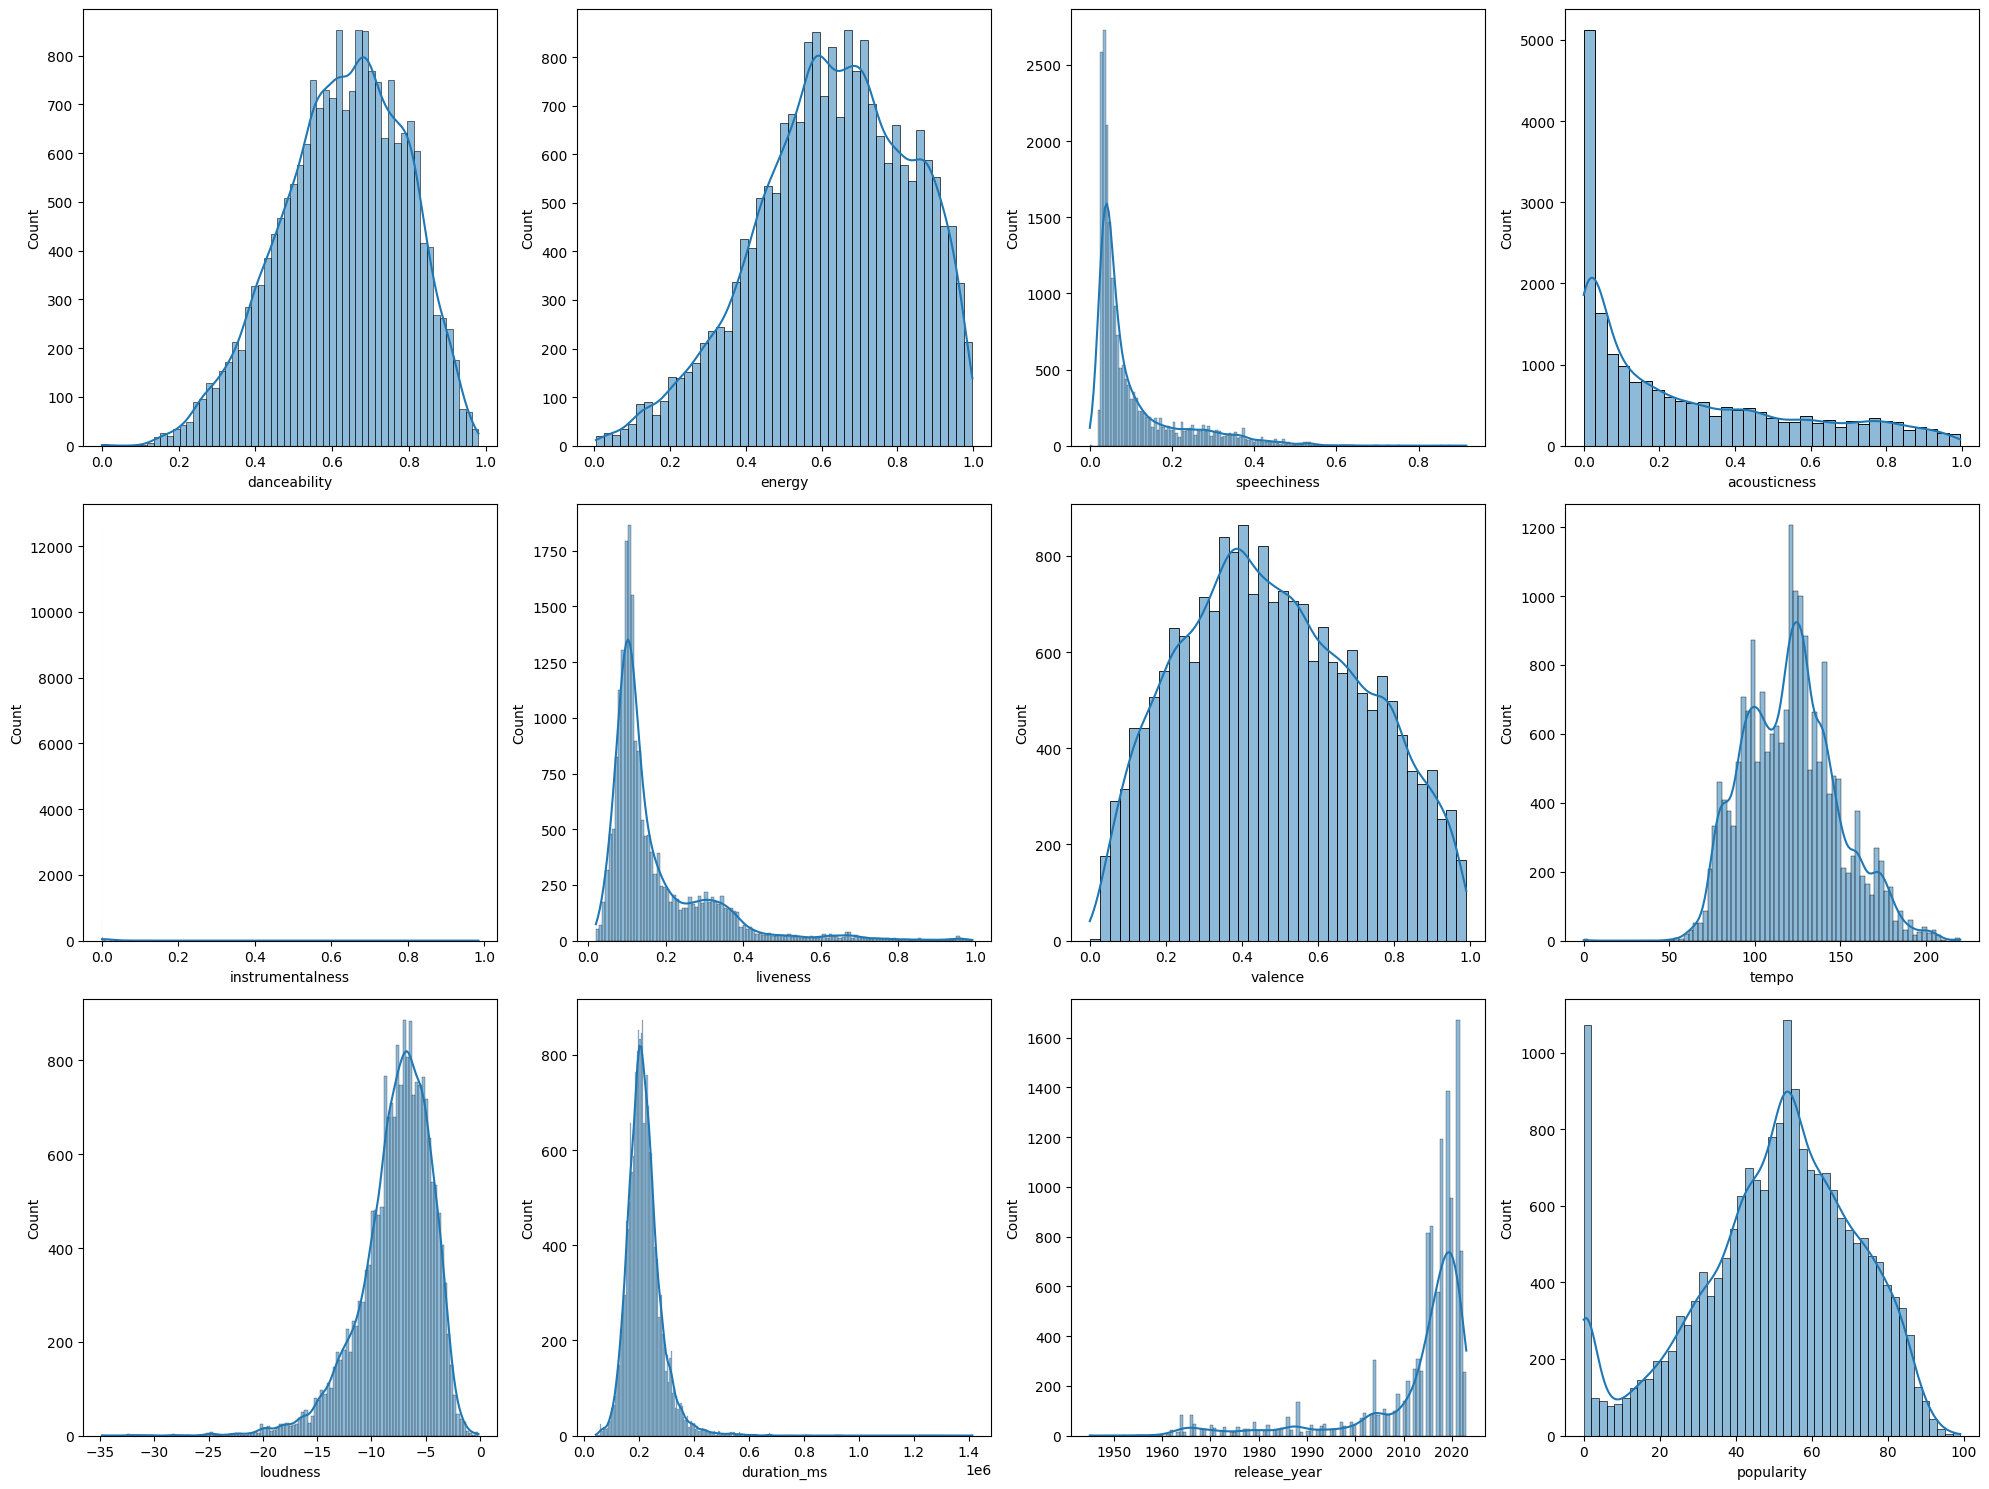

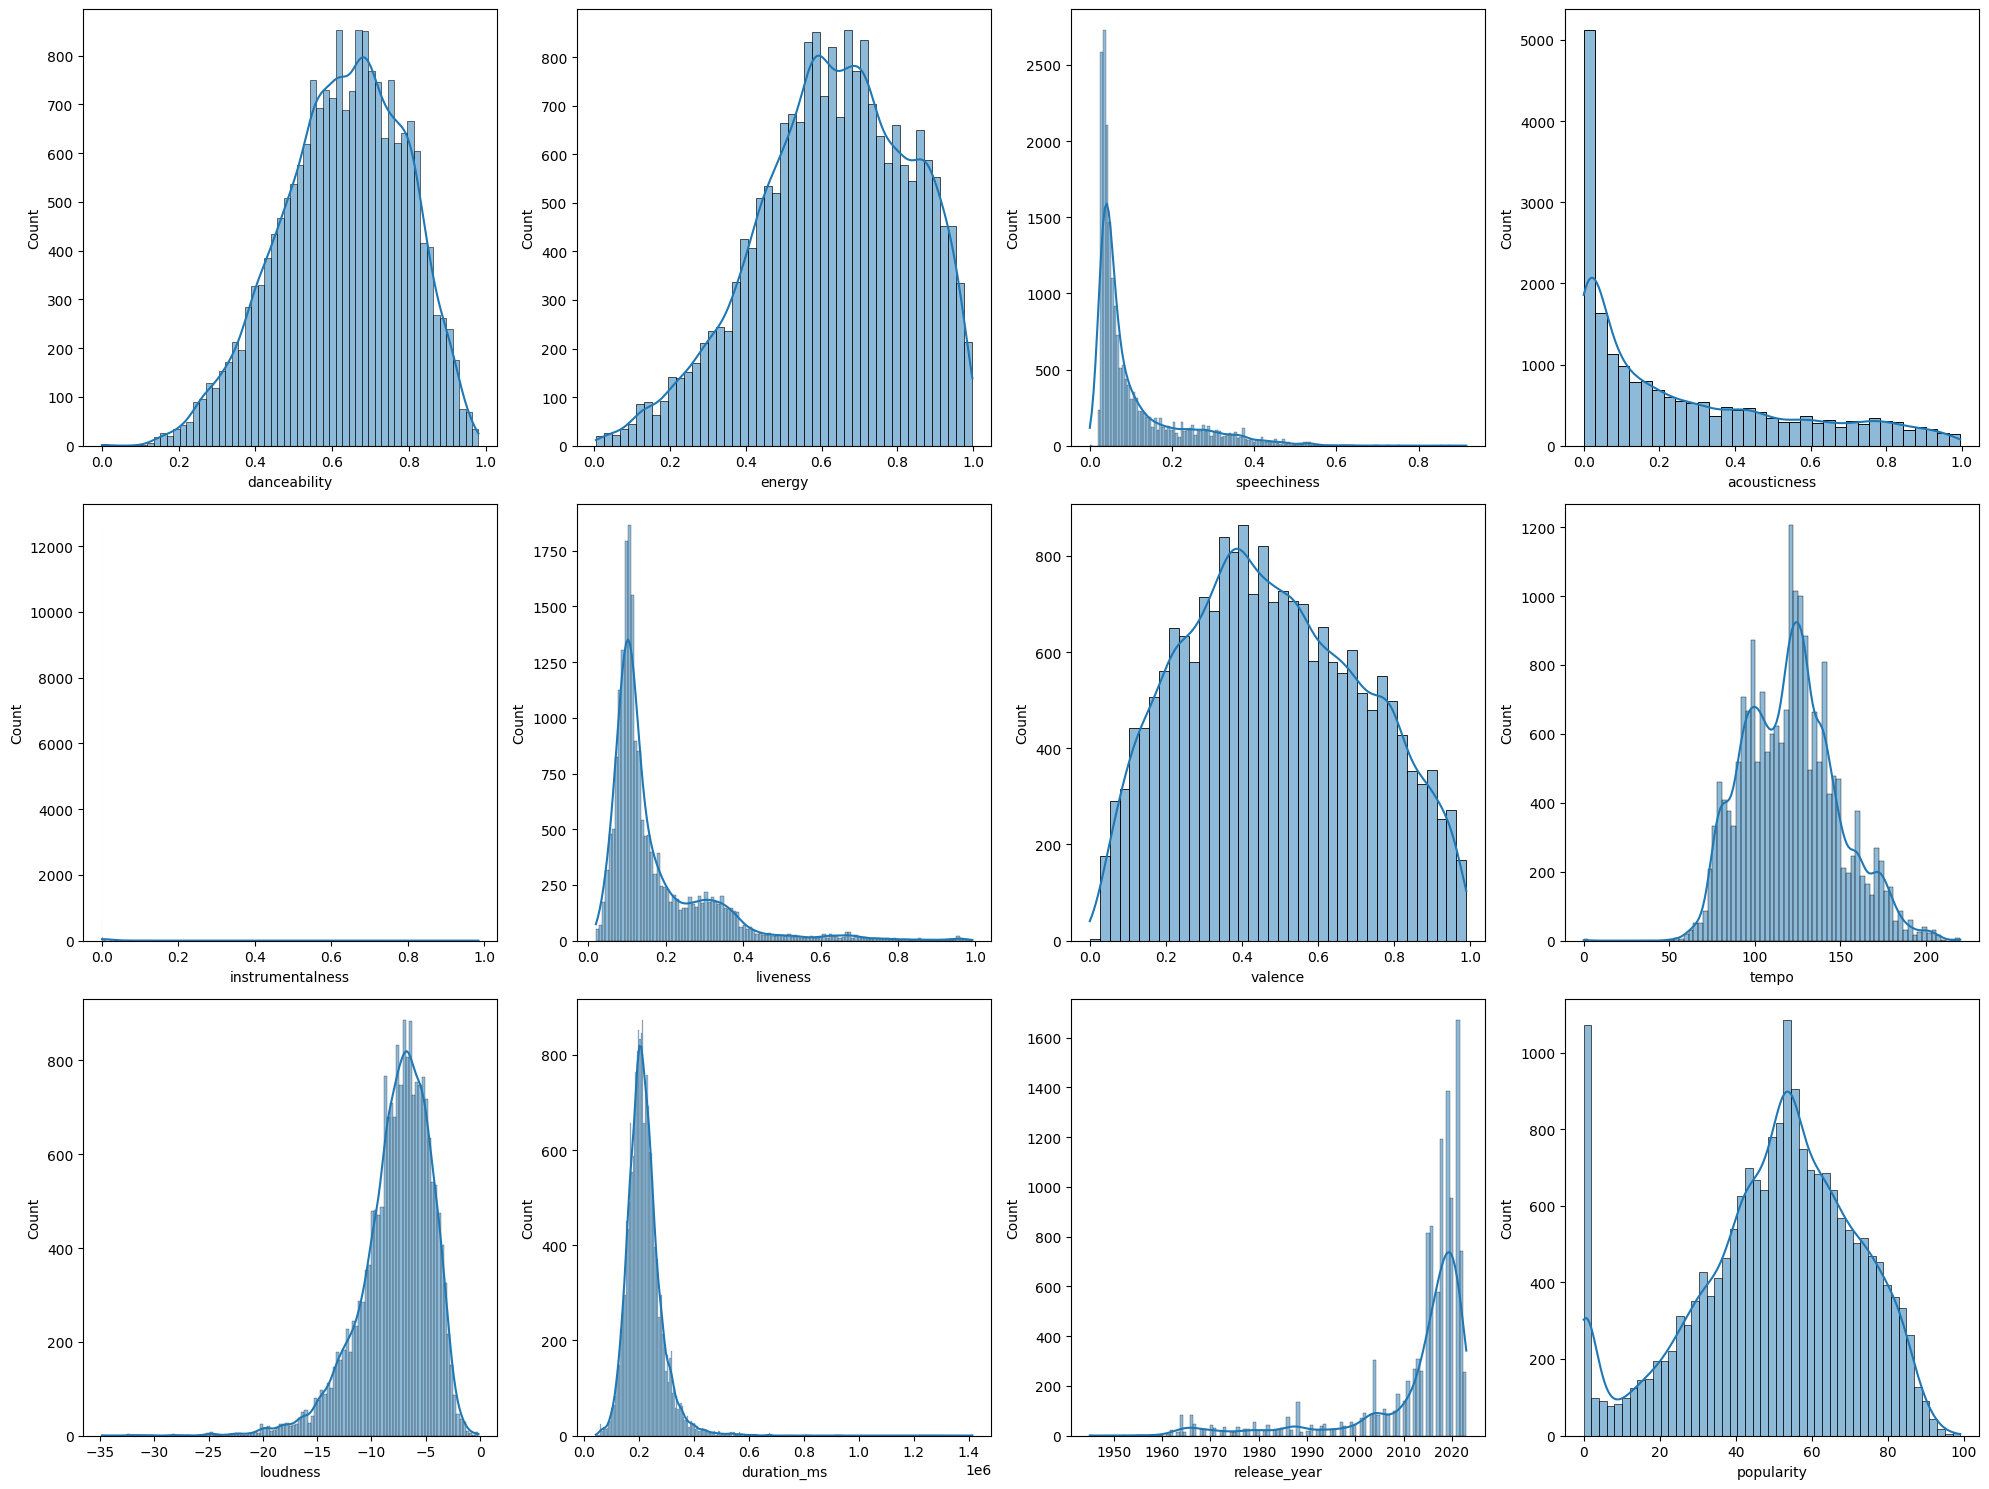

In [11]:
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=4, rows=3)

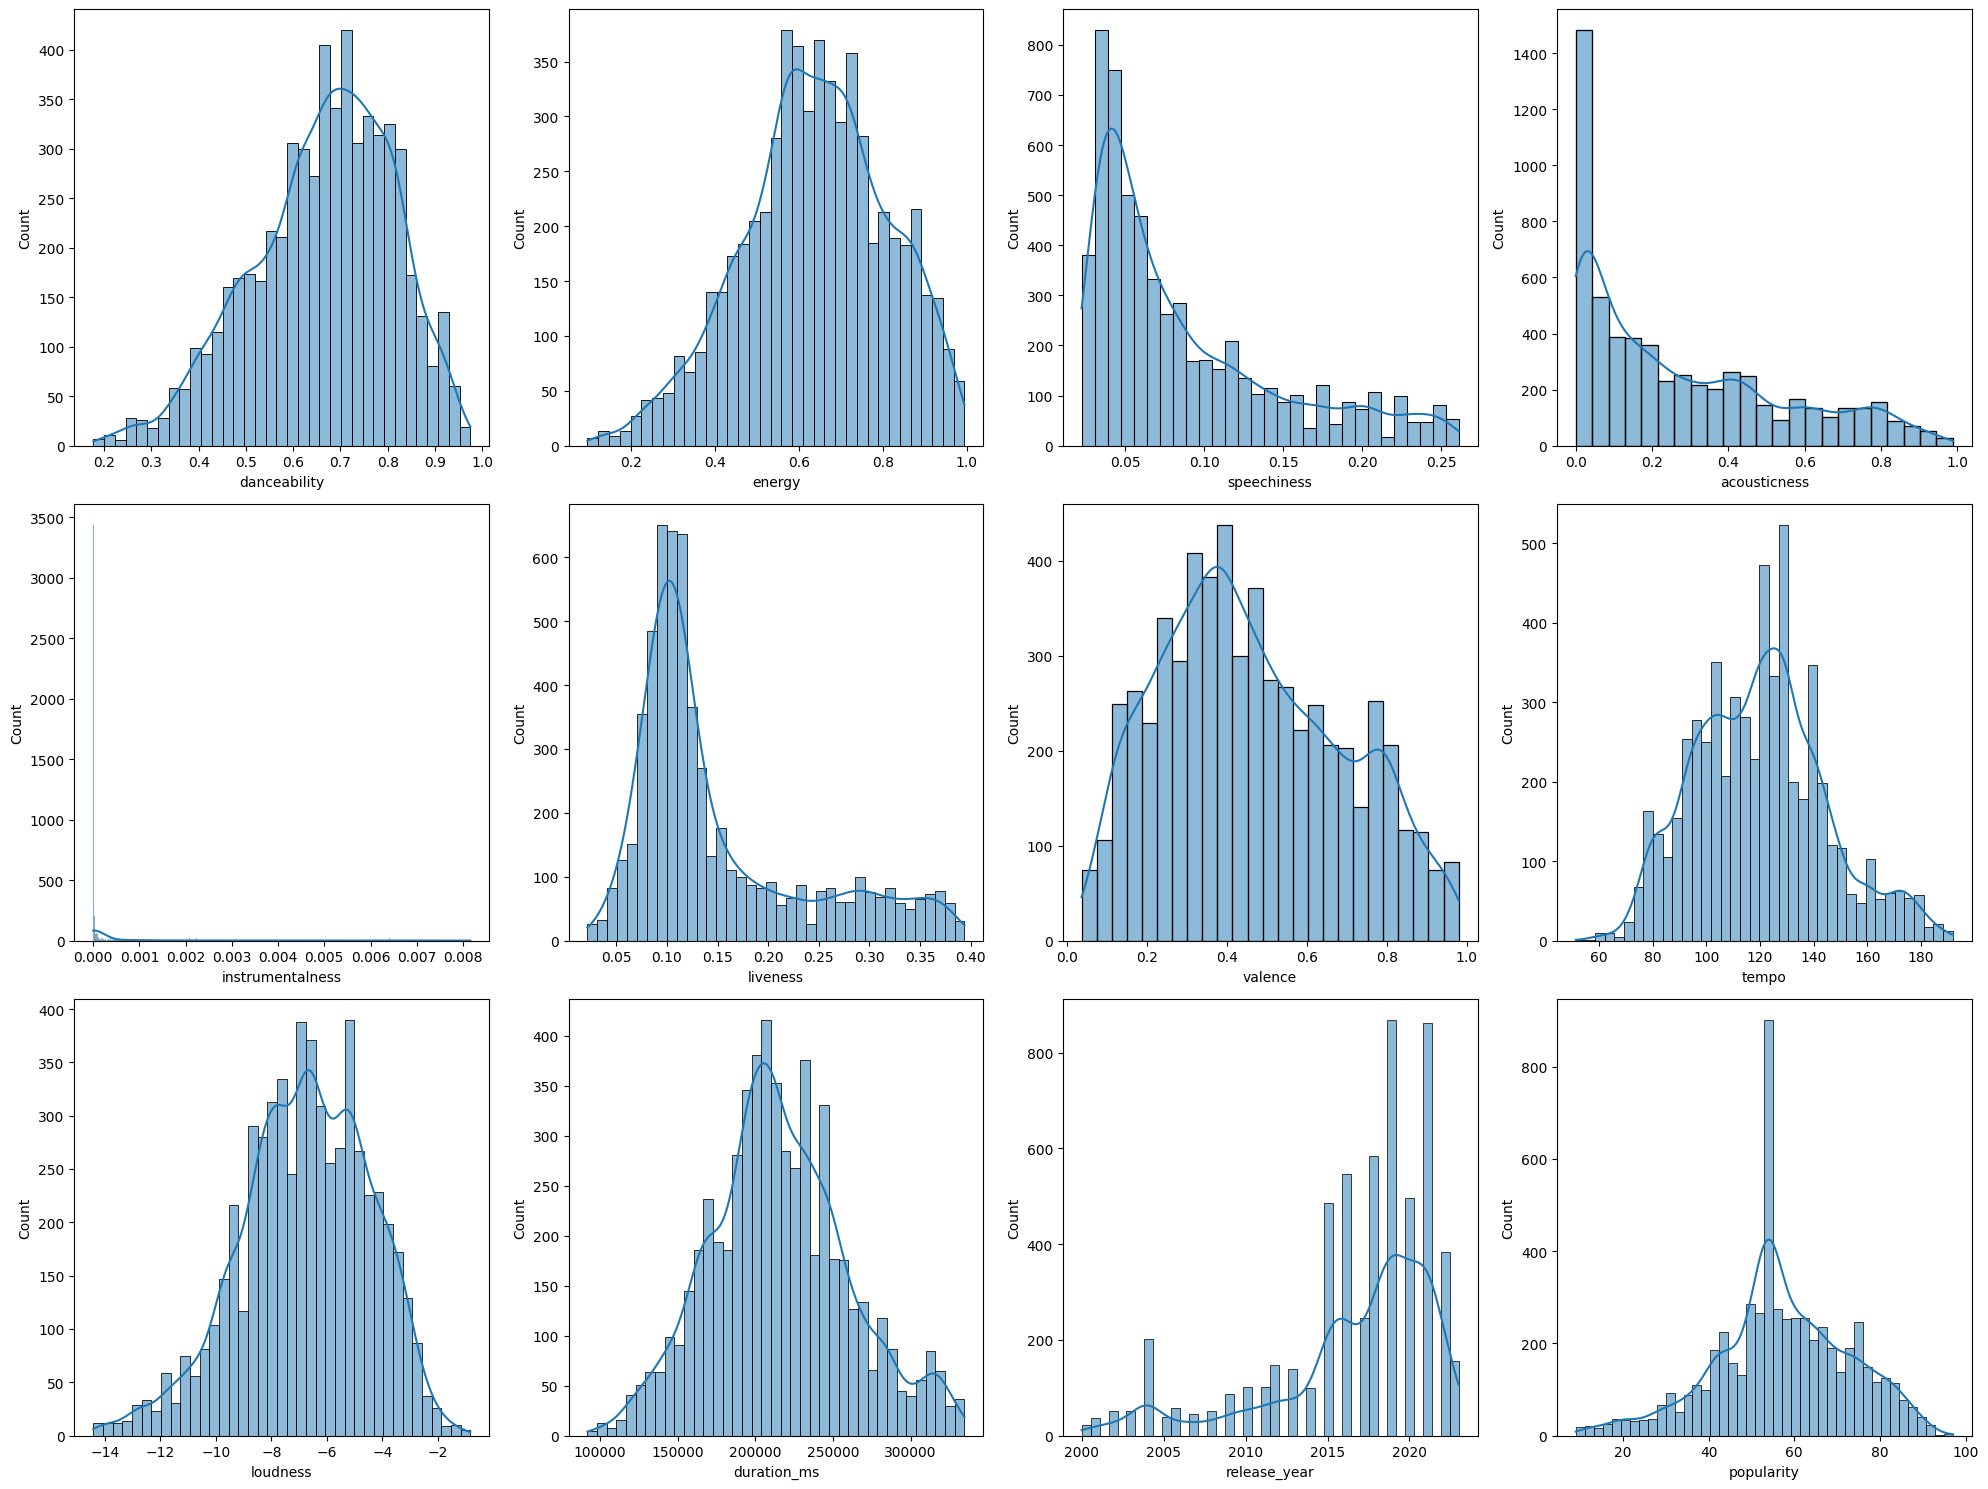

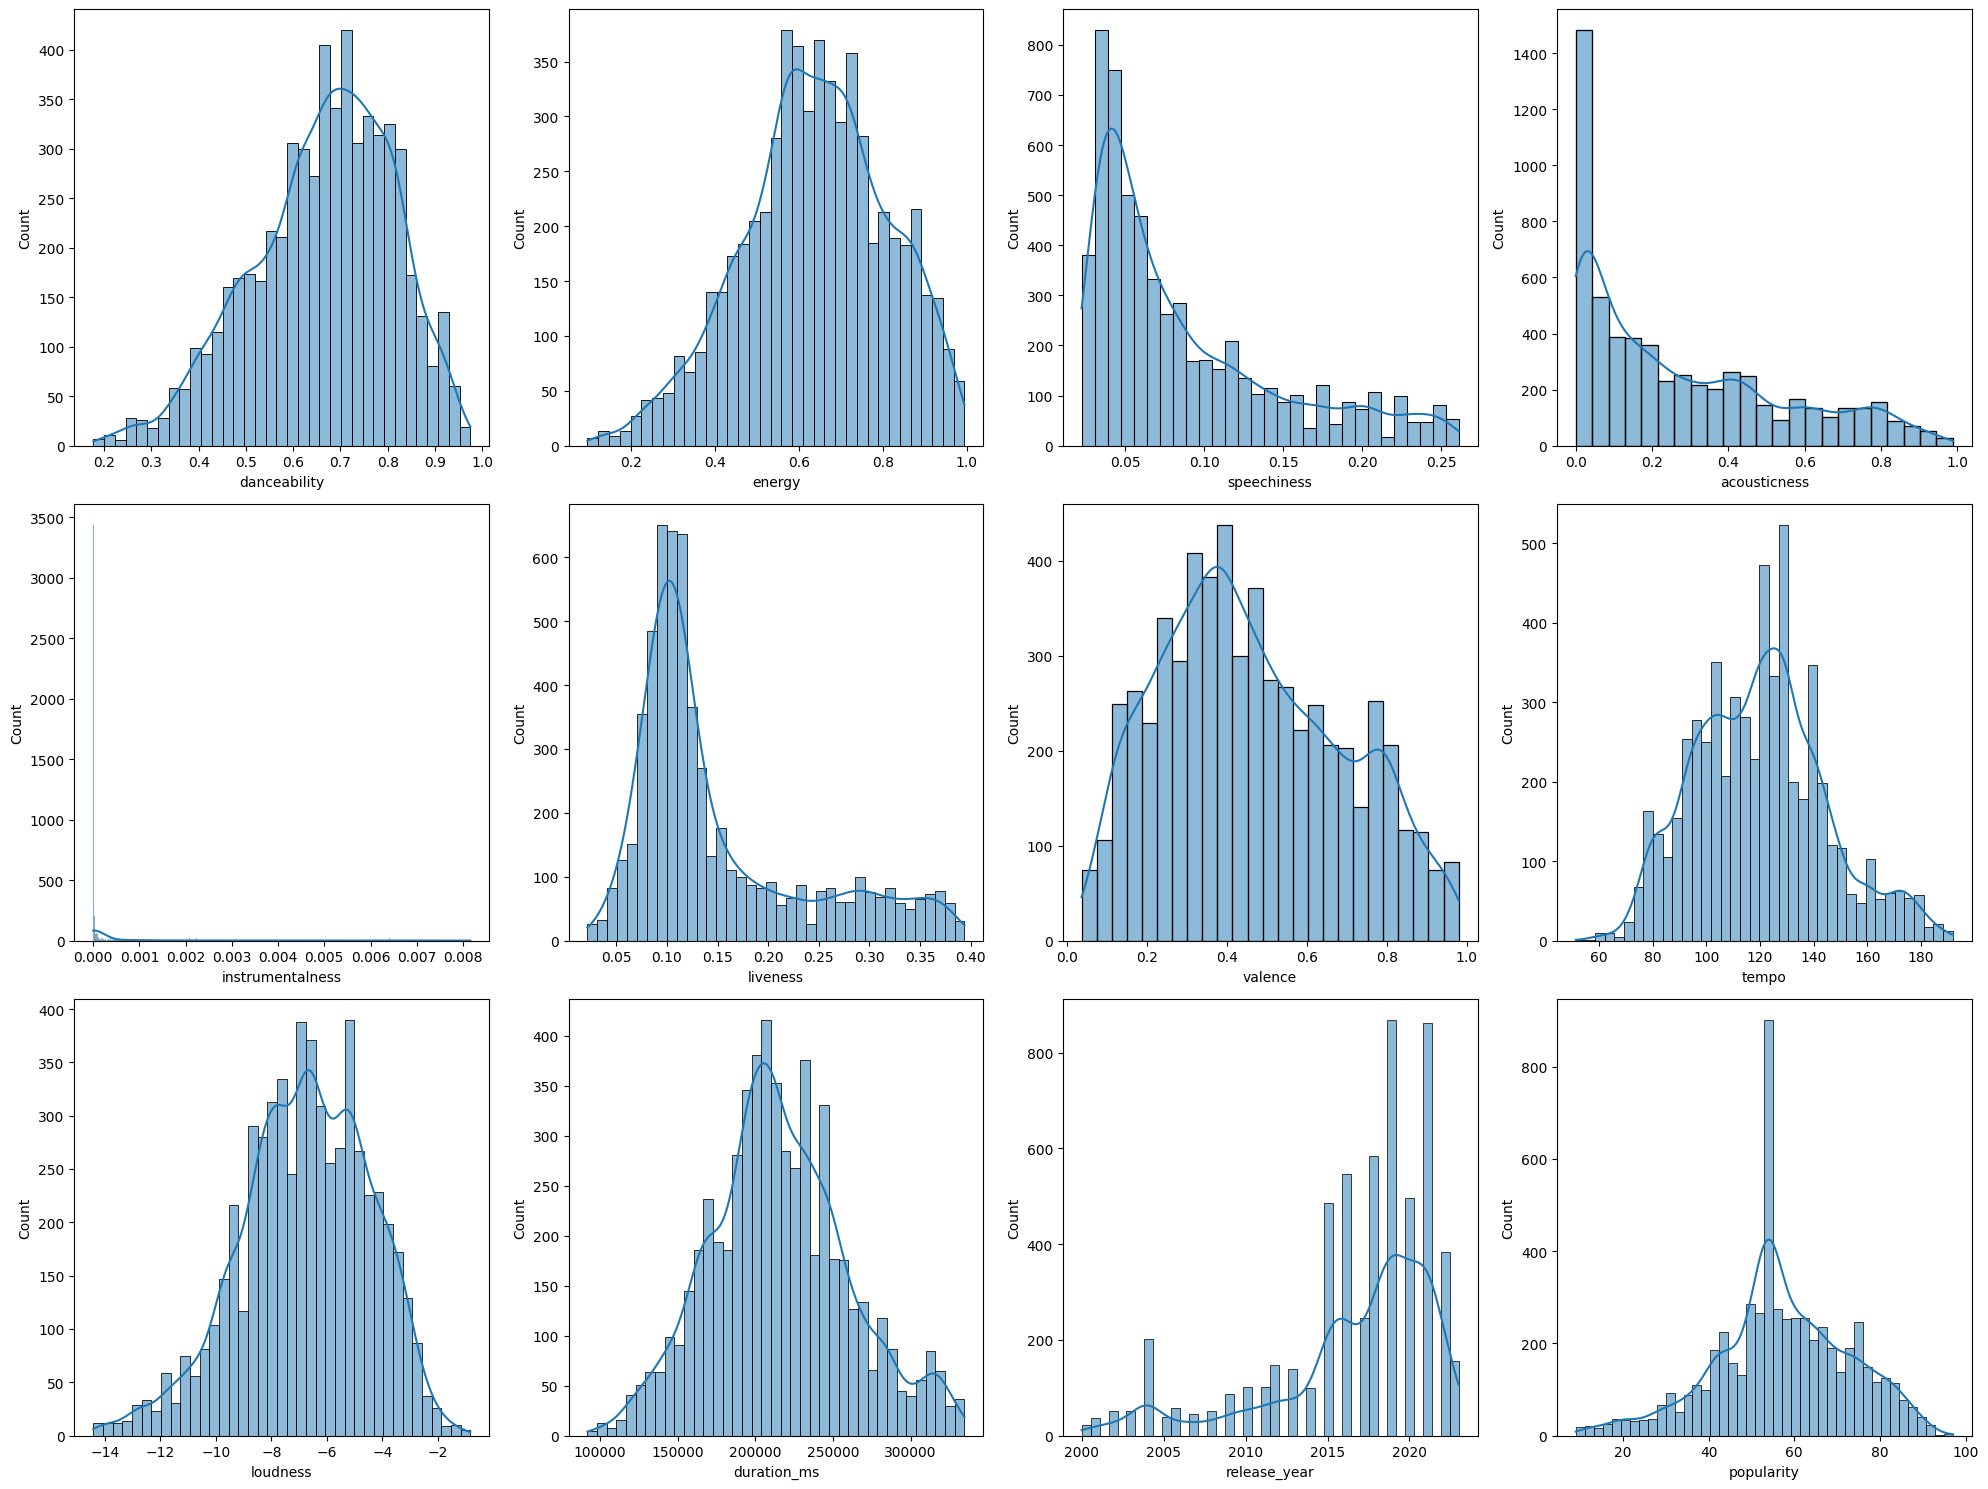

In [12]:
# Remove outliers based on IQR
df = preprocessing.remove_outliers_iqr(df, spoti.NUMERICAL_FEATURES, quantile=0.25, threshold=1.5)
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=4, rows=3)

In [13]:
plotting.plot_genres(df["genres"])

In [14]:
plotting.plot_genres(df["normalized_genres"])

# KNN

In [15]:
spoti.TRACKS_TYPES

['top_track', 'liked_track', 'playlist']

In [16]:
# From a user's perspective, we want to recommend songs that are similar to the songs that the user has listened to.
# We can use the cosine similarity to find the most similar songs to a given song.
df_knn = df.copy()

# df_knn = remove_outliers_iqr(df_knn, NUMERICAL_FEATURES, threshold=0.15)

# normalize numeric features
scaler = StandardScaler()
df_knn[spoti.NUMERICAL_FEATURES] = scaler.fit_transform(df_knn[spoti.NUMERICAL_FEATURES])

# Run PCA on the numeric features
n_components = len(spoti.NUMERICAL_FEATURES)
n_components = 8
pca = PCA(n_components=n_components)
latent_features = pca.fit_transform(df_knn[spoti.NUMERICAL_FEATURES])
df_knn, latent_columns = dimensionality_reduction.add_latent_features(df_knn, latent_features)
if n_components <= 3: plotting.plot_latent_space(df_knn, color=df_knn["username"], text=df_knn["username"], title="PCA").show()
latent_columns = spoti.NUMERICAL_FEATURES

# Choose a user
user = np.random.choice(users_list.USERS)
user = user.username
user = "paul"
print(f"User: {user}")

# Get songs that the user has listened to
track_types = ["top_track"]
df_knn_user = df_knn[df_knn["username"] == user]
df_knn_user = df_knn_user[df_knn_user["type"].isin(track_types)]
df_knn_user

# Sample N songs from the songs that the user has listened to, more chance of sampling central songs of the user
PRE_SELECT_N = 20
SELECT_N = 10
df_knn_user_sample = df_knn_user.sample(PRE_SELECT_N)
# sort by affinity with random weights
weights = np.random.rand(len(df_knn_user_sample)) * 2 + 1
df_knn_user_sample["affinity"] = df_knn_user_sample["affinity"] * weights
df_knn_user_sample = df_knn_user_sample.sort_values(by="affinity", ascending=False)
df_knn_user_sample = df_knn_user_sample.drop_duplicates(subset=["id"])
df_knn_user_sample = df_knn_user_sample.head(SELECT_N)
# shuffle the dataframe
display(df_knn_user_sample[spoti.PRETTY_PRINT_FEATURES + latent_columns])

# Get songs that the user has not listened to
df_knn_user_complement = df_knn[(~df_knn["id"].isin(df_knn_user["id"])) & (~df_knn["id"].isin(df_knn_user_sample["id"]))].drop_duplicates(subset=["id"])
df_knn_not_user = df_knn[(df_knn["username"] != user) & (~df_knn["id"].isin(df_knn_user_sample["id"]))].drop_duplicates(subset=["id"])

print(f"User songs selected: {len(df_knn_user)}")
print(f"User songs complement: {len(df_knn_user_complement)}")
print(f"Songs unknown to user: {len(df_knn_not_user)}")

# Get the songs that are most similar to the sampled songs
knn = NearestNeighbors(metric="minkowski", p=2, radius=1)

# From all the songs that the user has not listened to, we only want to consider the songs that are similar to the sampled songs
choosen_df = df_knn_user_complement
knn.fit(choosen_df[latent_columns])
distances, indices = knn.kneighbors(df_knn_user_sample[latent_columns], n_neighbors=1000, return_distance=True)
# Set the distances to the original dataframe
choosen_df = choosen_df.iloc[indices.flatten()].copy()
choosen_df["distance"] = distances.flatten()
choosen_df = choosen_df.sort_values(by="distance")
choosen_df = choosen_df.drop_duplicates(subset=["id"])

TOP_N = 20
choosen_df = choosen_df.head(TOP_N)
# shuffle the dataframe
choosen_df = choosen_df.sample(frac=1)

choosen_df[spoti.PRETTY_PRINT_FEATURES]

User: paul


,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
18096,paul,PLK,Dingue,0.461743,0.064501,0.077082,0.210766,0.211909,-0.474669,-0.258104,...,0.211909,-0.474669,-0.258104,1.805414,1.136718,1.807258,0.889712,-0.839140,0.461743,0.064501
18149,paul,Jack Harlow,Tyler Herro,0.657227,1.332027,0.866174,0.892145,-0.053475,-0.708826,-0.352487,...,-0.053475,-0.708826,-0.352487,0.802336,1.389352,0.126950,0.258751,-1.315275,0.657227,1.332027
18092,paul,A$AP Rocky,"A$AP Forever REMIX (feat. Moby, T.I. & Kid Cudi)",0.266259,0.444759,-1.588778,0.666943,1.530482,0.097462,-0.352487,...,1.530482,0.097462,-0.352487,-0.166152,-0.299310,0.246457,0.159667,2.243665,0.266259,0.444759
18153,paul,Damso,Humains - Bonus Track,0.266259,-0.062252,-0.368046,0.401321,-0.560875,-0.849017,-0.331820,...,-0.560875,-0.849017,-0.331820,-0.689597,1.699605,1.642562,-0.676754,0.416745,0.266259,-0.062252
18191,paul,Damso,MEVTR,0.852710,-0.696015,-0.260136,0.014436,1.964443,-0.448147,-0.214982,...,1.964443,-0.448147,-0.214982,0.836925,-0.370225,0.579372,0.139507,-1.120444,0.852710,-0.696015
18095,paul,PLK,Polak,0.461743,-0.315757,1.452934,0.274284,1.280120,1.059854,-0.352487,...,1.280120,1.059854,-0.352487,-0.442863,0.440865,0.457611,-0.729513,-0.932252,0.461743,-0.315757
18105,paul,13 Block,Vrai négro,-0.124708,-1.266402,1.385490,-0.487936,0.208571,0.646859,-0.260545,...,0.208571,0.646859,-0.260545,-0.558159,-1.653343,0.413652,-1.199195,1.553741,-0.124708,-1.266402
18110,paul,La Fève,MAUVAIS PAYEUR,0.852710,0.444759,1.473167,-0.678491,1.613936,-0.994134,-0.269495,...,1.613936,-0.994134,-0.269495,-0.581219,-0.046676,-0.284258,-1.032769,-1.728344,0.852710,0.444759
18162,paul,PNL,DA,-0.124708,0.634888,0.346857,0.251187,0.211909,0.192185,-0.349069,...,0.211909,0.192185,-0.349069,-0.664232,-1.442814,-0.692187,-0.397089,0.326427,-0.124708,0.634888
18215,paul,Kendrick Lamar,King Kunta,-0.320192,1.205274,1.486656,0.106827,0.173520,-1.016906,-0.352487,...,0.173520,-1.016906,-0.352487,0.041381,0.121747,-0.527410,0.951908,0.431052,-0.320192,1.205274


User songs selected: 88
User songs complement: 2631
Songs unknown to user: 2386


,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
10443,owen,thaHomey,CASINO (feat. La Fève),1.048194,-0.886144,0.009638,-0.164570,2.047897,0.362688,-0.352487,-0.027797,-0.051108,1.149171,-0.131579,-1.262963,1.048194,-0.886144
11016,owen,Leto,Ouais Ouais (feat. Hamza),0.852710,-0.505886,0.650354,0.262735,2.047897,-0.118508,-0.352487,0.156677,-0.068837,0.739684,0.195268,-0.242977,0.852710,-0.505886
19259,lsirwguhu,Maroon 5,What Lovers Do (feat. SZA),0.266259,1.078522,0.913384,-0.239637,-0.437363,-0.740653,-0.347881,-0.581219,-0.188506,-0.406878,0.710847,-0.347915,0.266259,1.078522
19576,lsirwguhu,Seeed,Augenbling,-0.906642,0.318006,1.277580,0.233863,0.428890,-1.004061,-0.352487,0.283503,-0.325903,-0.709927,1.183532,0.029407,-0.906642,0.318006
13436,owen,PNL,DA,-0.124708,-0.189004,0.346857,0.251187,0.211909,0.192185,-0.349069,-0.664232,-1.442814,-0.692187,-0.397089,0.326427,-0.124708,-0.189004
12999,owen,Damso,Ρ. DOSE,0.852710,-0.822767,1.061760,-0.366674,1.730772,0.230075,-0.345335,-0.535100,-0.144184,0.657664,-1.099254,-0.554327,0.852710,-0.822767
14177,owen,PNL,91's,0.461743,-0.189004,0.778497,0.383998,-0.076842,0.010316,-0.352487,-0.807199,-1.035053,-0.691737,-0.448561,0.406528,0.461743,-0.189004
15246,brenda,Lomepal,1000°C,0.266259,0.254630,0.286158,-0.493710,0.412199,-0.042729,-0.324497,-0.454393,-0.308175,-0.693867,-0.543784,0.458170,0.266259,0.254630
10745,owen,Voyou,Seul sur ton tandem,0.461743,-0.822767,0.124293,0.239638,-0.704416,-0.436780,-0.318395,-0.781834,1.061371,0.986072,-0.321168,0.359514,0.461743,-0.822767
19028,paul,Jason Derulo,Want to Want Me,-0.320192,1.395403,0.751519,0.239638,-0.407320,-1.004895,-0.352487,-0.477452,0.861922,-0.242019,0.549139,-0.171974,-0.320192,1.395403
